# 📊 Unemployment Rate Analysis & Covid-19 Impact

## Project Overview

This project analyzes unemployment rate data using Python to identify trends, patterns, and the impact of the Covid-19 pandemic on employment. The analysis includes data cleaning, exploratory data analysis (EDA), visualization, and statistical insights that can help understand changes in unemployment across different regions and time periods.

### Objectives
- Clean and preprocess the unemployment dataset.
- Explore unemployment trends using statistical analysis.
- Analyze the impact of Covid-19 on unemployment rates.
- Identify monthly and seasonal patterns.
- Generate insights to support economic and social policy decisions.

### Tools & Libraries
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Plotly

In [3]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings("ignore")
# Set visualization style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [6]:
# Load Dataset
#df = sns.load_dataset("Unemployment_Rate.csv")
df = pd.read_csv("global_unemployment_data.csv")
print("✅ Dataset Loaded Successfully!")

✅ Dataset Loaded Successfully!


In [7]:
# First 5 Rows
df.head()

,country_name,indicator_name,sex,age_group,age_categories,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Afghanistan,Unemployment rate by sex and age,Female,15-24,Youth,13.340,15.974,18.570,21.137,20.649,20.154,21.228,21.640,30.561,32.200,33.332
1,Afghanistan,Unemployment rate by sex and age,Female,25+,Adults,8.576,9.014,9.463,9.920,11.223,12.587,14.079,14.415,23.818,26.192,28.298
2,Afghanistan,Unemployment rate by sex and age,Female,Under 15,Children,10.306,11.552,12.789,14.017,14.706,15.418,16.783,17.134,26.746,29.193,30.956
3,Afghanistan,Unemployment rate by sex and age,Male,15-24,Youth,9.206,11.502,13.772,16.027,15.199,14.361,14.452,15.099,16.655,18.512,19.770
4,Afghanistan,Unemployment rate by sex and age,Male,25+,Adults,6.463,6.879,7.301,7.728,7.833,7.961,8.732,9.199,11.357,12.327,13.087


In [8]:
# Last 5 Rows
df.tail()

,country_name,indicator_name,sex,age_group,age_categories,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
1129,Zimbabwe,Unemployment rate by sex and age,Female,25+,Adults,4.262,4.586,4.773,4.900,5.027,5.309,6.345,7.792,7.704,7.597,7.528
1130,Zimbabwe,Unemployment rate by sex and age,Female,Under 15,Children,5.174,5.666,6.014,6.289,6.555,6.990,8.494,9.853,9.670,9.518,9.414
1131,Zimbabwe,Unemployment rate by sex and age,Male,15-24,Youth,6.007,7.131,8.119,9.029,9.927,11.048,13.191,14.261,13.966,13.675,13.485
1132,Zimbabwe,Unemployment rate by sex and age,Male,25+,Adults,3.677,4.325,4.843,5.287,5.722,6.362,6.996,7.234,6.858,6.757,6.703
1133,Zimbabwe,Unemployment rate by sex and age,Male,Under 15,Children,4.355,5.152,5.821,6.410,6.984,7.760,8.809,9.223,8.842,8.713,8.632


In [ ]:
# Number of Rows and Columns
print("Dataset Shape:", df.shape)
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Dataset Shape: (1134, 16)
Number of Rows: 1134
Number of Columns: 16


In [ ]:
# Display Column Names
print("Columns in Dataset:\n")
for column in df.columns:
    print(column)

Columns in Dataset:

country_name
indicator_name
sex
age_group
age_categories
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
2024


In [ ]:
# Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1134 entries, 0 to 1133
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country_name    1134 non-null   str    
 1   indicator_name  1134 non-null   str    
 2   sex             1134 non-null   str    
 3   age_group       1134 non-null   str    
 4   age_categories  1134 non-null   str    
 5   2014            1134 non-null   float64
 6   2015            1134 non-null   float64
 7   2016            1134 non-null   float64
 8   2017            1134 non-null   float64
 9   2018            1134 non-null   float64
 10  2019            1134 non-null   float64
 11  2020            1134 non-null   float64
 12  2021            1134 non-null   float64
 13  2022            1128 non-null   float64
 14  2023            1122 non-null   float64
 15  2024            1122 non-null   float64
dtypes: float64(11), str(5)
memory usage: 206.5 KB


In [ ]:
# Statistical Summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
2014,1134.0,11.387800,11.119002,0.027,3.93350,7.6975,15.05075,74.485
2015,1134.0,11.272444,10.915942,0.034,3.99350,7.5475,14.76625,74.655
2016,1134.0,11.122963,10.742947,0.038,3.94525,7.5045,14.46750,74.720
2017,1134.0,10.863516,10.640980,0.035,3.74750,7.1405,14.14200,75.416
2018,1134.0,10.516499,10.527773,0.044,3.67275,6.7060,13.34300,76.395
2019,1134.0,10.311452,10.297952,0.036,3.53850,6.6275,13.28550,77.173
2020,1134.0,11.851285,11.231580,0.056,4.33450,8.0675,15.31625,83.990
2021,1134.0,11.422645,10.873412,0.064,4.15350,7.5425,14.88150,82.135
2022,1128.0,10.340361,10.264810,0.067,3.55525,6.5715,13.41000,78.776
2023,1122.0,9.985181,9.987778,0.063,3.47750,6.4660,12.91450,78.541


In [13]:
# Missing Values
missing_values = df.isnull().sum()
print(missing_values)

country_name       0
indicator_name     0
sex                0
age_group          0
age_categories     0
2014               0
2015               0
2016               0
2017               0
2018               0
2019               0
2020               0
2021               0
2022               6
2023              12
2024              12
dtype: int64


In [14]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage

country_name      0.000000
indicator_name    0.000000
sex               0.000000
age_group         0.000000
age_categories    0.000000
2014              0.000000
2015              0.000000
2016              0.000000
2017              0.000000
2018              0.000000
2019              0.000000
2020              0.000000
2021              0.000000
2022              0.529101
2023              1.058201
2024              1.058201
dtype: float64

In [15]:
# Duplicate Rows
duplicates = df.duplicated().sum()
print("Total Duplicate Rows:", duplicates)

Total Duplicate Rows: 0


In [16]:
# Data Types
df.dtypes

country_name          str
indicator_name        str
sex                   str
age_group             str
age_categories        str
2014              float64
2015              float64
2016              float64
2017              float64
2018              float64
2019              float64
2020              float64
2021              float64
2022              float64
2023              float64
2024              float64
dtype: object

In [17]:
# Random Sample
df.sample(5)

,country_name,indicator_name,sex,age_group,age_categories,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
374,Georgia,Unemployment rate by sex and age,Female,Under 15,Children,14.480,13.936,12.578,12.724,11.245,10.169,10.226,10.375,10.266,10.329,10.519
824,Qatar,Unemployment rate by sex and age,Female,Under 15,Children,1.030,0.870,0.717,0.628,0.452,0.398,0.521,0.450,0.388,0.424,0.448
219,Comoros,Unemployment rate by sex and age,Male,15-24,Youth,9.768,9.748,9.680,9.490,9.275,9.232,10.378,9.796,9.805,9.927,9.987
842,Rwanda,Unemployment rate by sex and age,Female,Under 15,Children,12.637,12.623,12.567,12.650,11.356,12.078,12.904,17.466,16.610,16.458,16.340
262,Czechia,Unemployment rate by sex and age,Male,25+,Adults,4.323,3.703,2.907,1.997,1.510,1.510,1.941,2.006,1.546,1.790,1.776


### 📘 Part 2: Data Cleaning & Feature Engineering

In [18]:
# Create a Copy of Original Dataset
df_clean = df.copy()
print("✅ Copy Created Successfully!")

✅ Copy Created Successfully!


In [19]:
# Display Column Names
print(df_clean.columns.tolist())

['country_name', 'indicator_name', 'sex', 'age_group', 'age_categories', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']


In [20]:
# Rename Columns
df_clean.rename(columns={
    "country_name": "Country",
    "indicator_name": "Indicator",
    "sex": "Gender",
    "age_group": "Age_Group",
    "age_categories": "Age_Category"
}, inplace=True)
print("✅ Columns Renamed Successfully!")

✅ Columns Renamed Successfully!


In [21]:
df_clean.columns

Index(['Country', 'Indicator', 'Gender', 'Age_Group', 'Age_Category', '2014',
       '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023',
       '2024'],
      dtype='str')

In [22]:
# Convert Column Names to Lowercase
df_clean.columns = df_clean.columns.str.lower()
df_clean.columns

Index(['country', 'indicator', 'gender', 'age_group', 'age_category', '2014',
       '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023',
       '2024'],
      dtype='str')

In [23]:
# Missing Values
df_clean.isnull().sum()

country          0
indicator        0
gender           0
age_group        0
age_category     0
2014             0
2015             0
2016             0
2017             0
2018             0
2019             0
2020             0
2021             0
2022             6
2023            12
2024            12
dtype: int64

In [24]:
missing_percentage = (
    df_clean.isnull().sum()/len(df_clean)
)*100
missing_percentage.sort_values(ascending=False)

2024            1.058201
2023            1.058201
2022            0.529101
country         0.000000
age_category    0.000000
indicator       0.000000
gender          0.000000
age_group       0.000000
2016            0.000000
2015            0.000000
2014            0.000000
2017            0.000000
2020            0.000000
2019            0.000000
2018            0.000000
2021            0.000000
dtype: float64

In [25]:
missing_percentage = (
    df_clean.isnull().sum()/len(df_clean)
)*100
missing_percentage.sort_values(ascending=False)

2024            1.058201
2023            1.058201
2022            0.529101
country         0.000000
age_category    0.000000
indicator       0.000000
gender          0.000000
age_group       0.000000
2016            0.000000
2015            0.000000
2014            0.000000
2017            0.000000
2020            0.000000
2019            0.000000
2018            0.000000
2021            0.000000
dtype: float64

### Observation

Only the latest years (2022–2024) contain a few missing values, while the remaining columns are complete.

In [26]:
# Display Missing Records
df_clean[df_clean.isnull().any(axis=1)]

,country,indicator,gender,age_group,age_category,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
756,Palestinian Territories,Unemployment rate by sex and age,Female,15-24,Youth,51.653,56.179,60.753,66.914,69.188,66.831,69.503,64.249,56.709,NaN,NaN
757,Palestinian Territories,Unemployment rate by sex and age,Female,25+,Adults,20.681,28.478,31.496,35.803,35.161,35.022,33.515,37.921,36.385,NaN,NaN
758,Palestinian Territories,Unemployment rate by sex and age,Female,Under 15,Children,26.084,34.121,37.727,42.521,41.621,40.891,39.812,42.551,40.045,NaN,NaN
759,Palestinian Territories,Unemployment rate by sex and age,Male,15-24,Youth,33.669,33.242,33.696,36.220,36.698,34.448,36.227,36.866,31.563,NaN,NaN
760,Palestinian Territories,Unemployment rate by sex and age,Male,25+,Adults,14.085,15.385,15.868,16.334,17.476,17.043,18.443,17.955,16.772,NaN,NaN
761,Palestinian Territories,Unemployment rate by sex and age,Male,Under 15,Children,19.144,20.083,20.448,21.375,22.271,21.195,22.335,22.224,20.186,NaN,NaN
1056,Ukraine,Unemployment rate by sex and age,Female,15-24,Youth,22.811,22.116,21.759,16.976,19.305,15.365,18.539,20.412,NaN,NaN,NaN
1057,Ukraine,Unemployment rate by sex and age,Female,25+,Adults,6.292,6.990,6.669,7.069,6.615,7.345,8.508,9.519,NaN,NaN,NaN
1058,Ukraine,Unemployment rate by sex and age,Female,Under 15,Children,7.568,8.105,7.729,7.735,7.442,7.856,9.077,10.143,NaN,NaN,NaN
1059,Ukraine,Unemployment rate by sex and age,Male,15-24,Youth,24.177,22.940,24.103,20.388,16.926,15.486,19.900,18.085,NaN,NaN,NaN


In [27]:
duplicates = df_clean.duplicated().sum()
print("Duplicate Records :", duplicates)

Duplicate Records : 0


In [28]:
print("Total Countries :", df_clean["country"].nunique())

Total Countries : 189


In [29]:
sorted(df_clean["country"].unique())

['Afghanistan',
 'Albania',
 'Algeria',
 'Angola',
 'Argentina',
 'Armenia',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bhutan',
 'Bolivia',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'Brunei Darussalam',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cabo Verde',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Central African Republic',
 'Chad',
 'Channel Islands',
 'Chile',
 'China',
 'Colombia',
 'Comoros',
 'Congo',
 'Congo, Democratic Republic of the',
 'Costa Rica',
 'Croatia',
 'Cuba',
 'Cyprus',
 'Czechia',
 'Denmark',
 'Djibouti',
 'Dominican Republic',
 'Ecuador',
 'Egypt',
 'El Salvador',
 'Equatorial Guinea',
 'Eritrea',
 'Estonia',
 'Eswatini',
 'Ethiopia',
 'Fiji',
 'Finland',
 'France',
 'French Polynesia',
 'Gabon',
 'Gambia',
 'Georgia',
 'Germany',
 'Ghana',
 'Greece',
 'Guam',
 'Guatemala',
 'Guinea',
 'Guinea-Bissau',
 'Guyana',
 'Haiti',
 'Honduras',
 'Hong Kong, China',
 

In [30]:
df_clean["gender"].value_counts()
df_clean["age_group"].value_counts()
df_clean["age_category"].value_counts()
df_clean["indicator"].value_counts()
df_clean["indicator"].nunique()

1

In [31]:
df_clean.drop(columns="indicator", inplace=True)
print("Indicator Column Removed Successfully!")

Indicator Column Removed Successfully!


In [32]:
df_clean.info()
df_clean.head()

<class 'pandas.DataFrame'>
RangeIndex: 1134 entries, 0 to 1133
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country       1134 non-null   str    
 1   gender        1134 non-null   str    
 2   age_group     1134 non-null   str    
 3   age_category  1134 non-null   str    
 4   2014          1134 non-null   float64
 5   2015          1134 non-null   float64
 6   2016          1134 non-null   float64
 7   2017          1134 non-null   float64
 8   2018          1134 non-null   float64
 9   2019          1134 non-null   float64
 10  2020          1134 non-null   float64
 11  2021          1134 non-null   float64
 12  2022          1128 non-null   float64
 13  2023          1122 non-null   float64
 14  2024          1122 non-null   float64
dtypes: float64(11), str(4)
memory usage: 162.2 KB


,country,gender,age_group,age_category,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Afghanistan,Female,15-24,Youth,13.340,15.974,18.570,21.137,20.649,20.154,21.228,21.640,30.561,32.200,33.332
1,Afghanistan,Female,25+,Adults,8.576,9.014,9.463,9.920,11.223,12.587,14.079,14.415,23.818,26.192,28.298
2,Afghanistan,Female,Under 15,Children,10.306,11.552,12.789,14.017,14.706,15.418,16.783,17.134,26.746,29.193,30.956
3,Afghanistan,Male,15-24,Youth,9.206,11.502,13.772,16.027,15.199,14.361,14.452,15.099,16.655,18.512,19.770
4,Afghanistan,Male,25+,Adults,6.463,6.879,7.301,7.728,7.833,7.961,8.732,9.199,11.357,12.327,13.087


In [33]:
df_clean.to_csv("clean_unemployment_data.csv", index=False)

print("✅ Clean Dataset Saved Successfully!")

✅ Clean Dataset Saved Successfully!


# 📊 Exploratory Data Analysis (EDA)

## Overview

Exploratory Data Analysis (EDA) is performed to understand the structure of the dataset, identify patterns, detect anomalies, and gain meaningful insights before advanced analysis.

### Goals of EDA

- Explore the distribution of unemployment rates.
- Analyze country, gender, and age-wise records.
- Identify trends across different years.
- Detect missing values and outliers.
- Understand the overall characteristics of the dataset using statistical and visual techniques.

In [34]:
print(f"Total Rows : {df_clean.shape[0]}")
print(f"Total Columns : {df_clean.shape[1]}")

Total Rows : 1134
Total Columns : 15


In [35]:
print("Total Countries :", df_clean["country"].nunique())
print("Gender Categories :", df_clean["gender"].nunique())
print("Age Groups :", df_clean["age_group"].nunique())
print("Age Categories :", df_clean["age_category"].nunique())

Total Countries : 189
Gender Categories : 2
Age Groups : 3
Age Categories : 3


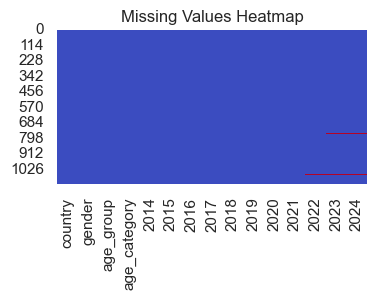

In [37]:
plt.figure(figsize=(4,2))
sns.heatmap(df_clean.isnull(),
            cbar=False,
            cmap="coolwarm")
plt.title("Missing Values Heatmap")
plt.show()

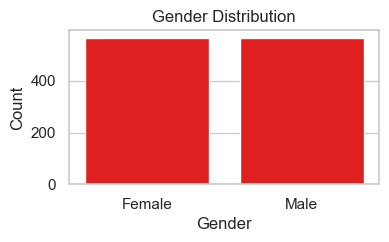

In [40]:
plt.figure(figsize=(4,2))
sns.countplot(data=df_clean,
              x="gender",color ='red')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

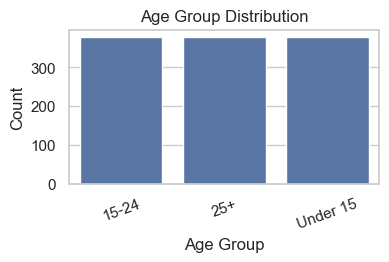

In [41]:
plt.figure(figsize=(4,2))
sns.countplot(data=df_clean,
              x="age_group")
plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()

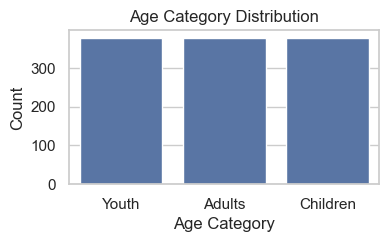

In [42]:
plt.figure(figsize=(4,2))
sns.countplot(data=df_clean,
              x="age_category")
plt.title("Age Category Distribution")
plt.xlabel("Age Category")
plt.ylabel("Count")
plt.show()

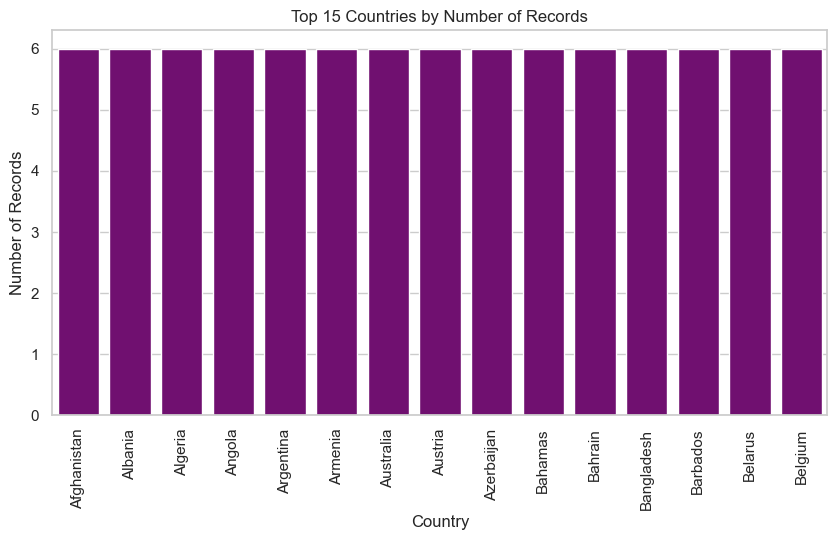

In [45]:
country_counts = (
    df_clean["country"]
    .value_counts()
    .head(15)
)
plt.figure(figsize=(10,5))
sns.barplot(
    x=country_counts.index,
    y=country_counts.values,color = 'purple'
)
plt.xticks(rotation=90)
plt.title("Top 15 Countries by Number of Records")
plt.xlabel("Country")
plt.ylabel("Number of Records")
plt.show()

In [46]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
2014,1134.0,11.387800,11.119002,0.027,3.93350,7.6975,15.05075,74.485
2015,1134.0,11.272444,10.915942,0.034,3.99350,7.5475,14.76625,74.655
2016,1134.0,11.122963,10.742947,0.038,3.94525,7.5045,14.46750,74.720
2017,1134.0,10.863516,10.640980,0.035,3.74750,7.1405,14.14200,75.416
2018,1134.0,10.516499,10.527773,0.044,3.67275,6.7060,13.34300,76.395
2019,1134.0,10.311452,10.297952,0.036,3.53850,6.6275,13.28550,77.173
2020,1134.0,11.851285,11.231580,0.056,4.33450,8.0675,15.31625,83.990
2021,1134.0,11.422645,10.873412,0.064,4.15350,7.5425,14.88150,82.135
2022,1128.0,10.340361,10.264810,0.067,3.55525,6.5715,13.41000,78.776
2023,1122.0,9.985181,9.987778,0.063,3.47750,6.4660,12.91450,78.541


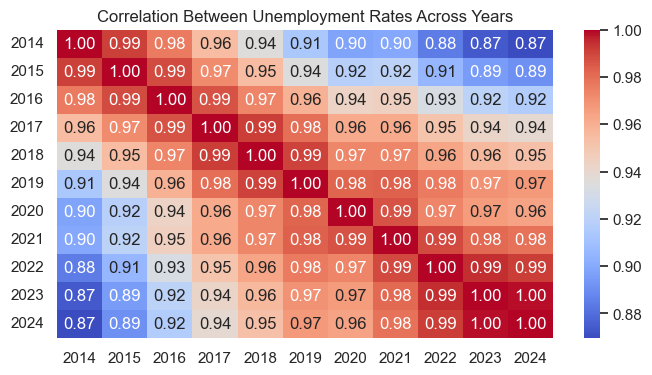

In [49]:
year_columns = [str(year) for year in range(2014, 2025)]
corr = df_clean[year_columns].corr()
plt.figure(figsize=(8,4))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Between Unemployment Rates Across Years")
plt.show()

# 📈 Data Transformation for Time Series Analysis

## Why Transform the Dataset?

The original dataset stores unemployment rates in a wide format, where each year is represented as a separate column.

For trend analysis and visualization, the dataset is transformed into a long format using the `melt()` function. This structure makes it easier to create time series charts, compare unemployment rates across years, and analyze the impact of Covid-19.

In [50]:
# Convert Wide Format to Long Format
df_long = df_clean.melt(
    id_vars=["country", "gender", "age_group", "age_category"],
    value_vars=[str(year) for year in range(2014, 2025)],
    var_name="year",
    value_name="unemployment_rate"
)
print("Dataset Converted Successfully!")

Dataset Converted Successfully!


In [51]:
df_long.head()
df_long.info()

<class 'pandas.DataFrame'>
RangeIndex: 12474 entries, 0 to 12473
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country            12474 non-null  str    
 1   gender             12474 non-null  str    
 2   age_group          12474 non-null  str    
 3   age_category       12474 non-null  str    
 4   year               12474 non-null  str    
 5   unemployment_rate  12444 non-null  float64
dtypes: float64(1), str(5)
memory usage: 955.8 KB


In [52]:
df_long["year"] = df_long["year"].astype(int)
df_long.info()

<class 'pandas.DataFrame'>
RangeIndex: 12474 entries, 0 to 12473
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country            12474 non-null  str    
 1   gender             12474 non-null  str    
 2   age_group          12474 non-null  str    
 3   age_category       12474 non-null  str    
 4   year               12474 non-null  int64  
 5   unemployment_rate  12444 non-null  float64
dtypes: float64(1), int64(1), str(4)
memory usage: 905.6 KB


In [53]:
df_long.isnull().sum()

country               0
gender                0
age_group             0
age_category          0
year                  0
unemployment_rate    30
dtype: int64

In [54]:
yearly_average = (
    df_long
    .groupby("year")["unemployment_rate"]
    .mean()
    .reset_index()
)
yearly_average

,year,unemployment_rate
0,2014,11.387800
1,2015,11.272444
2,2016,11.122963
3,2017,10.863516
4,2018,10.516499
5,2019,10.311452
6,2020,11.851285
7,2021,11.422645
8,2022,10.340361
9,2023,9.985181


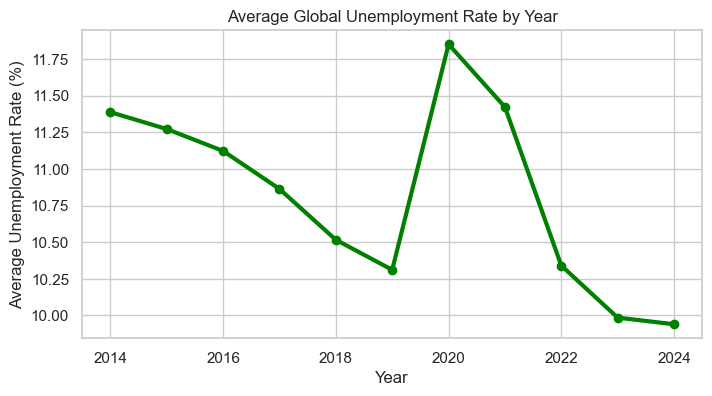

In [57]:
plt.figure(figsize=(8,4))
plt.plot(
    yearly_average["year"],
    yearly_average["unemployment_rate"],
    marker="o",
    linewidth=3,
    color = 'green'
)
plt.title("Average Global Unemployment Rate by Year")
plt.xlabel("Year")
plt.ylabel("Average Unemployment Rate (%)")
plt.grid(True)
plt.show()

In [58]:
fig = px.line(
    yearly_average,
    x="year",
    y="unemployment_rate",
    markers=True,
    title="Average Global Unemployment Rate Over Time"
)
fig.show()

In [59]:
gender_trend = (
    df_long
    .groupby(["year", "gender"])["unemployment_rate"]
    .mean()
    .reset_index()
)
gender_trend.head()

,year,gender,unemployment_rate
0,2014,Female,12.507709
1,2014,Male,10.267891
2,2015,Female,12.413287
3,2015,Male,10.131601
4,2016,Female,12.291407


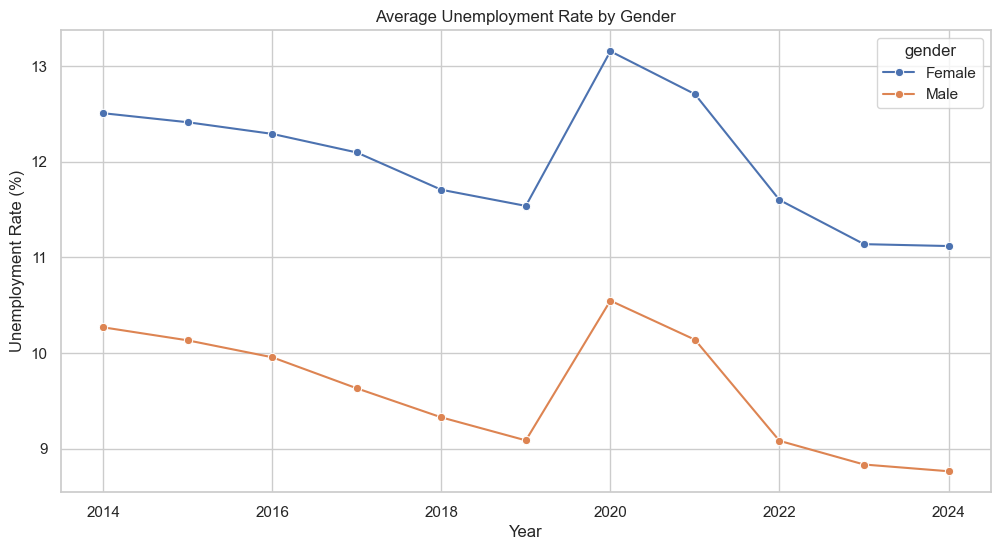

In [60]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=gender_trend,
    x="year",
    y="unemployment_rate",
    hue="gender",
    marker="o"
)
plt.title("Average Unemployment Rate by Gender")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate (%)")
plt.show()

In [61]:
fig = px.line(
    gender_trend,
    x="year",
    y="unemployment_rate",
    color="gender",
    markers=True,
    title="Gender-wise Unemployment Trend"
)
fig.show()

In [62]:
age_trend = (
    df_long
    .groupby(["year", "age_category"])["unemployment_rate"]
    .mean()
    .reset_index()
)
age_trend.head()

,year,age_category,unemployment_rate
0,2014,Adults,6.744701
1,2014,Children,8.564595
2,2014,Youth,18.854103
3,2015,Adults,6.703299
4,2015,Children,8.484511


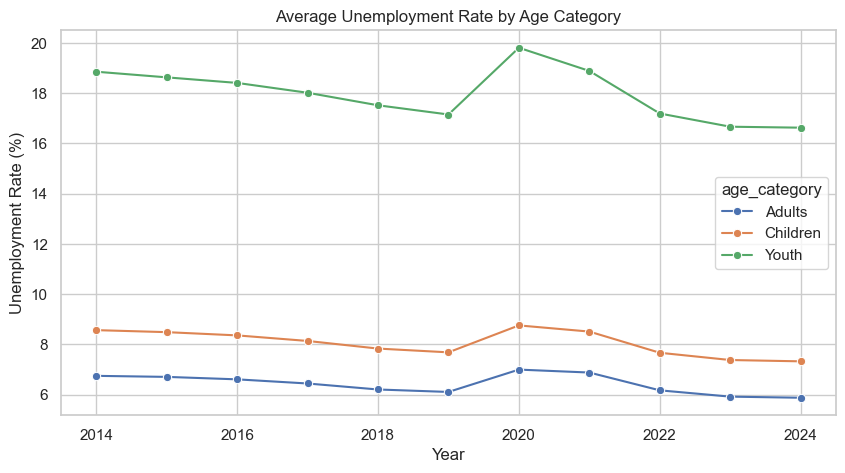

In [64]:
plt.figure(figsize=(10,5))
sns.lineplot(
    data=age_trend,
    x="year",
    y="unemployment_rate",
    hue="age_category",
    marker="o"
)
plt.title("Average Unemployment Rate by Age Category")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate (%)")
plt.show()

In [65]:
fig = px.line(
    age_trend,
    x="year",
    y="unemployment_rate",
    color="age_category",
    markers=True,
    title="Age Category-wise Unemployment Trend"
)
fig.show()

# 🦠 Covid-19 Impact Analysis

## Overview

The Covid-19 pandemic significantly affected labor markets across the world. Lockdowns, business closures, travel restrictions, and economic uncertainty resulted in increased unemployment in many countries.

This section analyzes unemployment trends before, during, and after the Covid-19 pandemic to understand how employment patterns changed over time.

In [66]:
# Create Covid Period Categories
df_long["covid_period"] = np.where(
    df_long["year"] <= 2019,
    "Before Covid",
    np.where(
        df_long["year"] <= 2021,
        "During Covid",
        "After Covid"
    )
)
df_long.head()

,country,gender,age_group,age_category,year,unemployment_rate,covid_period
0,Afghanistan,Female,15-24,Youth,2014,13.340,Before Covid
1,Afghanistan,Female,25+,Adults,2014,8.576,Before Covid
2,Afghanistan,Female,Under 15,Children,2014,10.306,Before Covid
3,Afghanistan,Male,15-24,Youth,2014,9.206,Before Covid
4,Afghanistan,Male,25+,Adults,2014,6.463,Before Covid


In [67]:
df_long["covid_period"].value_counts()

covid_period
Before Covid    6804
After Covid     3402
During Covid    2268
Name: count, dtype: int64

In [68]:
covid_avg = (
    df_long
    .groupby("covid_period")["unemployment_rate"]
    .mean()
    .reset_index()
)
covid_avg

,covid_period,unemployment_rate
0,After Covid,10.088992
1,Before Covid,10.912446
2,During Covid,11.636965


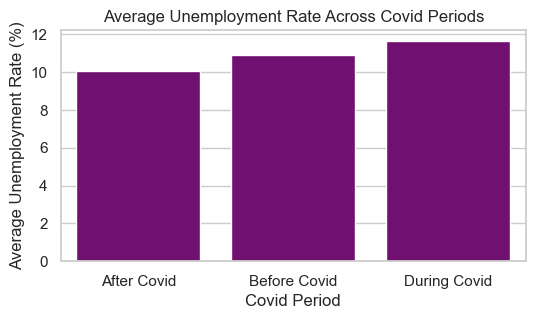

In [71]:
plt.figure(figsize=(6,3))
sns.barplot(
    data=covid_avg,
    x="covid_period",
    y="unemployment_rate",
    color = 'purple'
)
plt.title("Average Unemployment Rate Across Covid Periods")
plt.xlabel("Covid Period")
plt.ylabel("Average Unemployment Rate (%)")
plt.show()

In [72]:
# interactive covid comparison:
fig = px.bar(
    covid_avg,
    x="covid_period",
    y="unemployment_rate",
    color="covid_period",
    title="Average Unemployment Rate Across Covid Periods"
)
fig.show()

In [73]:
gender_covid = (
    df_long
    .groupby(["covid_period","gender"])["unemployment_rate"]
    .mean()
    .reset_index()
)
gender_covid

,covid_period,gender,unemployment_rate
0,After Covid,Female,11.285924
1,After Covid,Male,8.892059
2,Before Covid,Female,12.092408
3,Before Covid,Male,9.732484
4,During Covid,Female,12.931439
5,During Covid,Male,10.342490


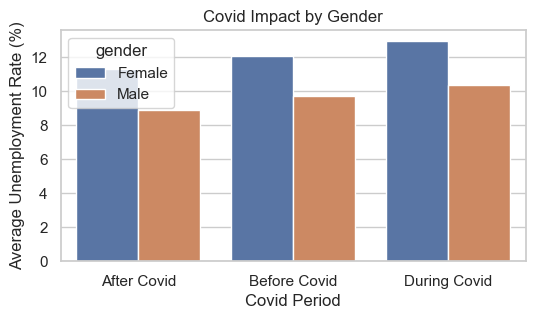

In [74]:
# gender comparison:
plt.figure(figsize=(6,3))
sns.barplot(
    data=gender_covid,
    x="covid_period",
    y="unemployment_rate",
    hue="gender"
)
plt.title("Covid Impact by Gender")
plt.xlabel("Covid Period")
plt.ylabel("Average Unemployment Rate (%)")
plt.show()

In [75]:
age_covid = (
    df_long
    .groupby(["covid_period","age_category"])["unemployment_rate"]
    .mean()
    .reset_index()
)
age_covid

,covid_period,age_category,unemployment_rate
0,After Covid,Adults,5.985931
1,After Covid,Children,7.453780
2,After Covid,Youth,16.827263
3,Before Covid,Adults,6.466417
4,Before Covid,Children,8.174964
5,Before Covid,Youth,18.095957
6,During Covid,Adults,6.934620
7,During Covid,Children,8.629959
8,During Covid,Youth,19.346315


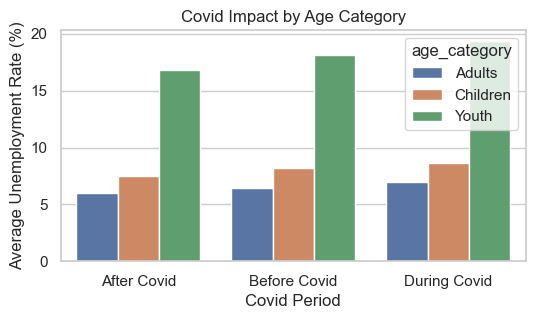

In [76]:
plt.figure(figsize=(6,3))
sns.barplot(
    data=age_covid,
    x="covid_period",
    y="unemployment_rate",
    hue="age_category"
)
plt.title("Covid Impact by Age Category")
plt.xlabel("Covid Period")
plt.ylabel("Average Unemployment Rate (%)")
plt.show()

In [77]:
top_countries = (
    df_long[df_long["covid_period"] == "After Covid"]
    .groupby("country")["unemployment_rate"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top_countries

,country,unemployment_rate
0,Djibouti,42.802611
1,South Africa,35.129556
2,Palestinian Territories,33.610000
3,Libya,30.374167
4,Eswatini,29.353167
5,Botswana,29.188500
6,Sudan,27.744944
7,Jordan,27.639222
8,Iraq,27.619722
9,Gabon,26.428833


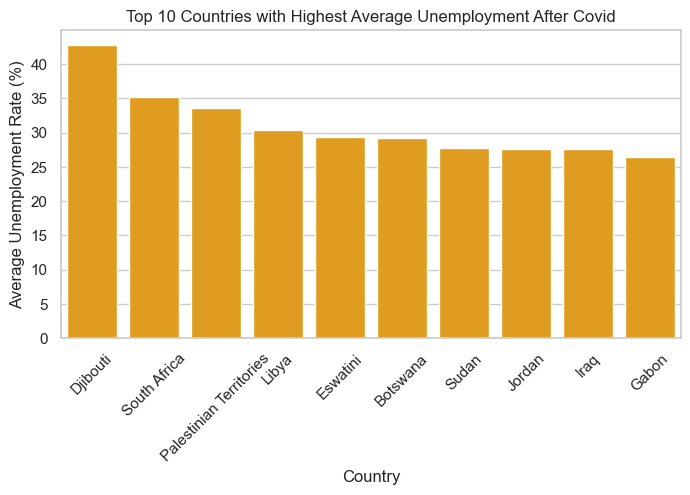

In [82]:
# top 10 most affected countries:
plt.figure(figsize=(8,4))
sns.barplot(
    data=top_countries,
    x="country",
    y="unemployment_rate",
    color = 'orange'
)
plt.xticks(rotation=45)
plt.title("Top 10 Countries with Highest Average Unemployment After Covid")
plt.xlabel("Country")
plt.ylabel("Average Unemployment Rate (%)")
plt.show()

In [83]:
# top 10 least most countries:
least_countries = (
    df_long[df_long["covid_period"] == "After Covid"]
    .groupby("country")["unemployment_rate"]
    .mean()
    .sort_values()
    .head(10)
    .reset_index()
)
least_countries

,country,unemployment_rate
0,Cambodia,0.352556
1,Qatar,0.447278
2,Niger,0.528056
3,Burundi,1.032167
4,Chad,1.037833
5,Cuba,1.662556
6,"Moldova, Republic of",1.873611
7,Solomon Islands,1.903778
8,Benin,2.052889
9,Madagascar,2.170500


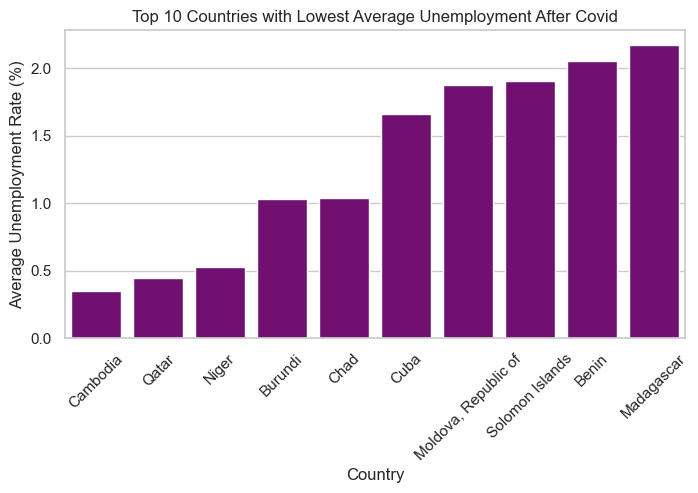

In [85]:
plt.figure(figsize=(8,4))
sns.barplot(
    data=least_countries,
    x="country",
    y="unemployment_rate",
    color = 'purple'
)
plt.xticks(rotation=45)
plt.title("Top 10 Countries with Lowest Average Unemployment After Covid")
plt.xlabel("Country")
plt.ylabel("Average Unemployment Rate (%)")
plt.show()

In [86]:
# covid percentage increase:
before = df_long[df_long["covid_period"]=="Before Covid"]["unemployment_rate"].mean()
during = df_long[df_long["covid_period"]=="During Covid"]["unemployment_rate"].mean()
after = df_long[df_long["covid_period"]=="After Covid"]["unemployment_rate"].mean()
increase = ((during-before)/before)*100
print(f"Before Covid : {before:.2f}")
print(f"During Covid : {during:.2f}")
print(f"After Covid : {after:.2f}")
print(f"Percentage Increase During Covid : {increase:.2f}%")

Before Covid : 10.91
During Covid : 11.64
After Covid : 10.09
Percentage Increase During Covid : 6.64%


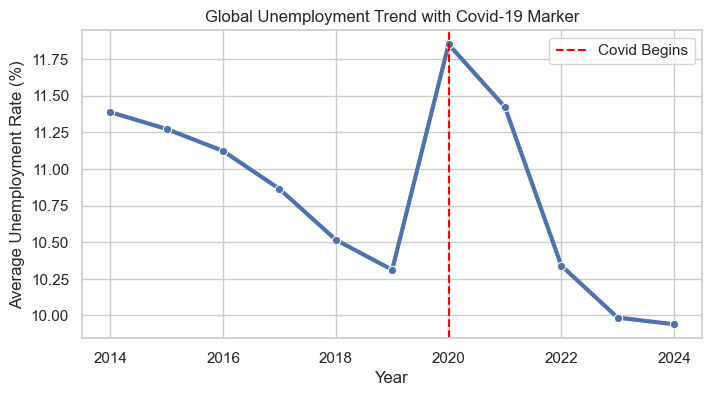

In [87]:
# covid trend line:
plt.figure(figsize=(8,4))
sns.lineplot(
    data=yearly_average,
    x="year",
    y="unemployment_rate",
    marker="o",
    linewidth=3
)
plt.axvline(
    x=2020,
    linestyle="--",
    color="red",
    label="Covid Begins"
)
plt.legend()
plt.title("Global Unemployment Trend with Covid-19 Marker")
plt.xlabel("Year")
plt.ylabel("Average Unemployment Rate (%)")
plt.show()

# 📊 Advanced Exploratory Data Analysis

## Overview

This section provides a deeper analysis of unemployment trends using advanced statistical visualizations.

The analysis focuses on:

- Distribution of unemployment rates
- Outlier detection
- Country-wise comparison
- Year-wise comparison
- Heatmap analysis
- Recovery trends after Covid-19

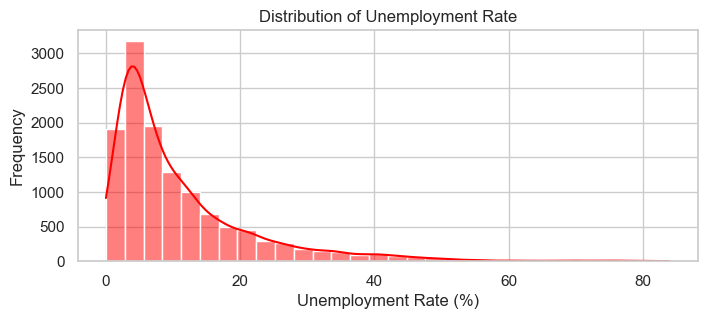

In [92]:
plt.figure(figsize=(8,3))
sns.histplot(
    data=df_long,
    x="unemployment_rate",
    bins=30,
    kde=True,
    color = 'red'
)
plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Frequency")
plt.show()

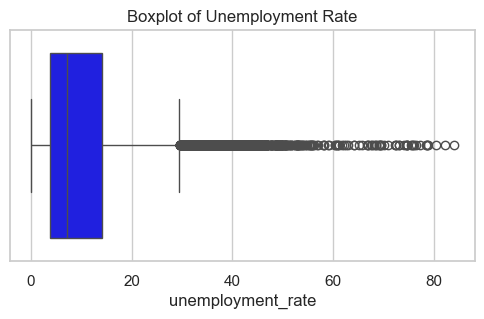

In [95]:
# outlier detection boxplot:
plt.figure(figsize=(6,3))
sns.boxplot(
    data=df_long,
    x="unemployment_rate",
    color = 'blue'
)
plt.title("Boxplot of Unemployment Rate")
plt.show()

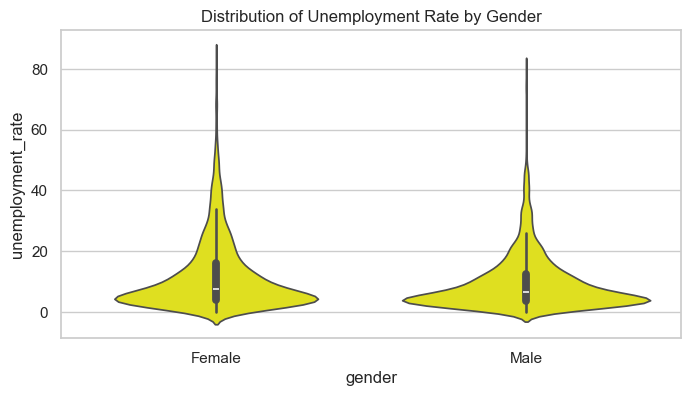

In [96]:
# violin plot:
plt.figure(figsize=(8,4))
sns.violinplot(
    data=df_long,
    x="gender",
    y="unemployment_rate",
    color = 'yellow'
)
plt.title("Distribution of Unemployment Rate by Gender")
plt.show()

In [97]:
# average unemployment of year:
avg_year = (
    df_long
    .groupby("year")["unemployment_rate"]
    .mean()
    .reset_index()
)
avg_year

,year,unemployment_rate
0,2014,11.387800
1,2015,11.272444
2,2016,11.122963
3,2017,10.863516
4,2018,10.516499
5,2019,10.311452
6,2020,11.851285
7,2021,11.422645
8,2022,10.340361
9,2023,9.985181


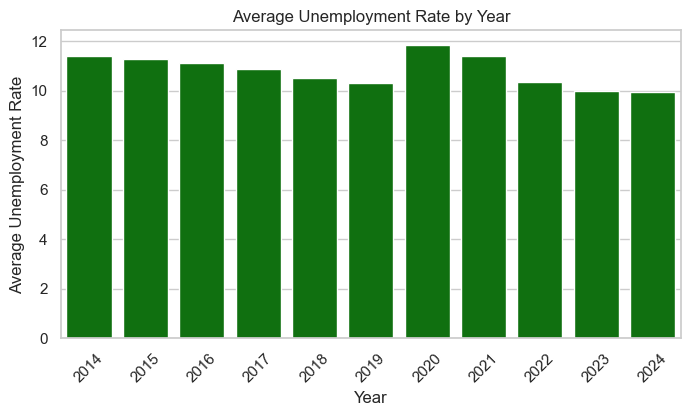

In [99]:
# year wise bar chart:
plt.figure(figsize=(8,4))
sns.barplot(
    data=avg_year,
    x="year",
    y="unemployment_rate",
    color = 'green'
)
plt.title("Average Unemployment Rate by Year")
plt.xlabel("Year")
plt.ylabel("Average Unemployment Rate")
plt.xticks(rotation=45)
plt.show()

In [100]:
top15 = (
    df_long
    .groupby("country")["unemployment_rate"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)
top15

,country,unemployment_rate
0,Djibouti,42.561576
1,Palestinian Territories,34.316019
2,South Africa,31.782045
3,Libya,31.120258
4,Eswatini,30.078288
5,Gabon,26.494470
6,Congo,26.420742
7,Bosnia and Herzegovina,26.204424
8,Botswana,25.972167
9,Sudan,25.942803


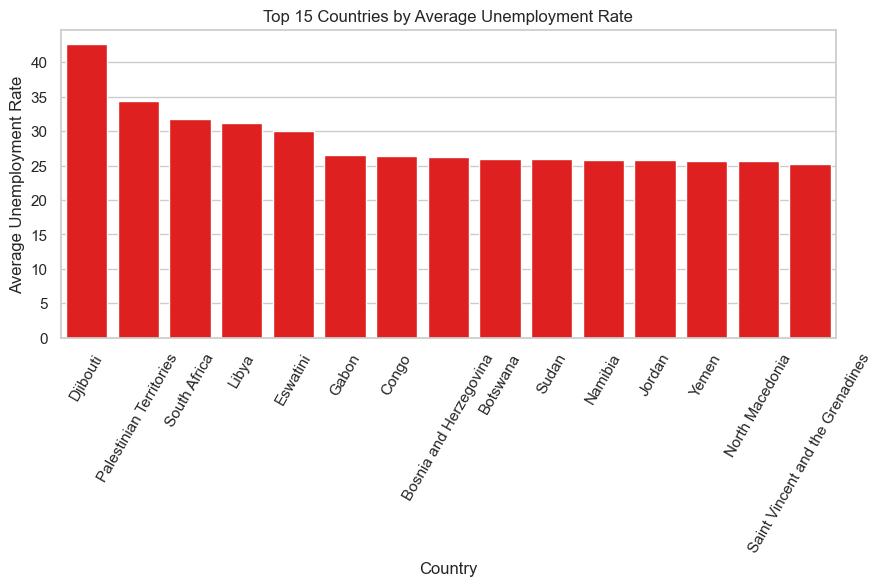

In [103]:
plt.figure(figsize=(10,4))
sns.barplot(
    data=top15,
    x="country",
    y="unemployment_rate",
    color = 'red'
)
plt.xticks(rotation=60)
plt.title("Top 15 Countries by Average Unemployment Rate")
plt.xlabel("Country")
plt.ylabel("Average Unemployment Rate")
plt.show()

In [104]:
# top 15 mose uemployment countries:
lowest15 = (
    df_long
    .groupby("country")["unemployment_rate"]
    .mean()
    .sort_values()
    .head(15)
    .reset_index()
)
lowest15

,country,unemployment_rate
0,Cambodia,0.410394
1,Qatar,0.575606
2,Niger,0.585015
3,Chad,1.154742
4,Solomon Islands,1.164212
5,Burundi,1.370848
6,"Moldova, Republic of",1.906985
7,Thailand,2.029061
8,Madagascar,2.153530
9,Benin,2.259636


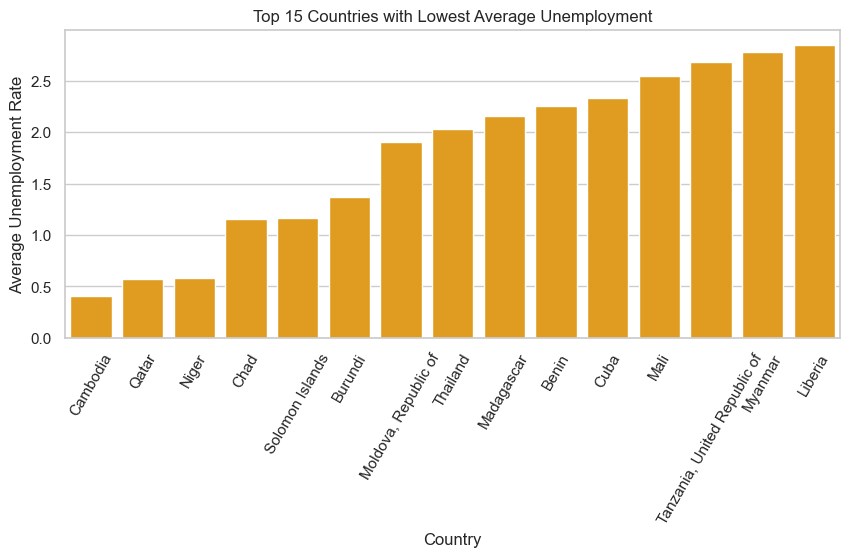

In [106]:
plt.figure(figsize=(10,4))
sns.barplot(
    data=lowest15,
    x="country",
    y="unemployment_rate",
    color ='orange'
)
plt.xticks(rotation=60)
plt.title("Top 15 Countries with Lowest Average Unemployment")
plt.xlabel("Country")
plt.ylabel("Average Unemployment Rate")
plt.show()

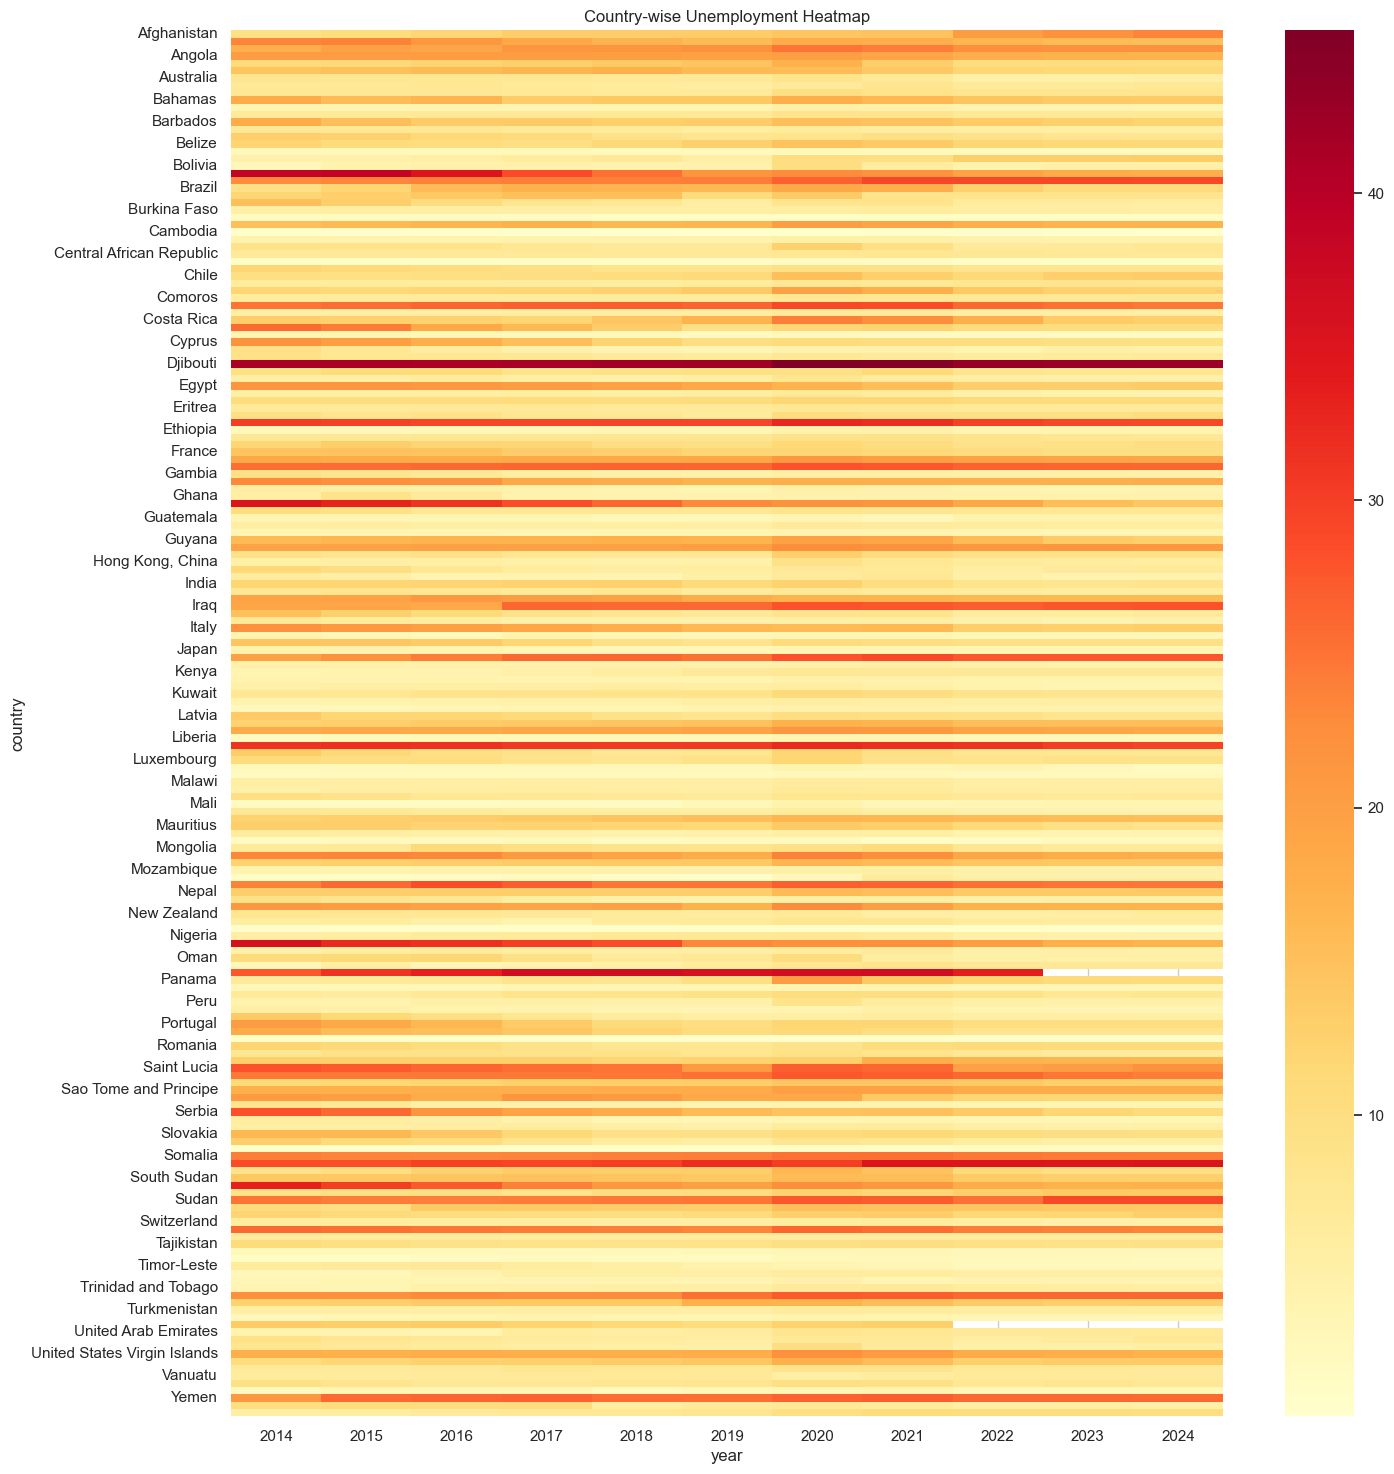

In [107]:
# country x year heatmap:
heatmap_data = df_long.pivot_table(
    values="unemployment_rate",
    index="country",
    columns="year",
    aggfunc="mean"
)
plt.figure(figsize=(16,18))
sns.heatmap(
    heatmap_data,
    cmap="YlOrRd"
)
plt.title("Country-wise Unemployment Heatmap")
plt.show()

In [108]:
# highest increase 2019 to 2020:
increase_df = (
    df_long[df_long["year"].isin([2019, 2020])]
    .pivot_table(
        index="country",
        columns="year",
        values="unemployment_rate",
        aggfunc="mean"
    )
)
increase_df["increase"] = increase_df[2020] - increase_df[2019]
increase_df = (
    increase_df
    .sort_values("increase", ascending=False)
    .head(15)
)
increase_df

year,2019,2020,increase
country,,,
Panama,9.777167,20.356833,10.579667
Costa Rica,17.082500,23.982000,6.899500
Colombia,13.600333,19.847667,6.247333
Saint Lucia,20.791667,26.830333,6.038667
New Caledonia,17.228833,22.913500,5.684667
Canada,7.079167,12.590333,5.511167
Montenegro,18.153167,23.656333,5.503167
Honduras,7.355500,12.804167,5.448667
Bolivia,4.566500,9.985667,5.419167


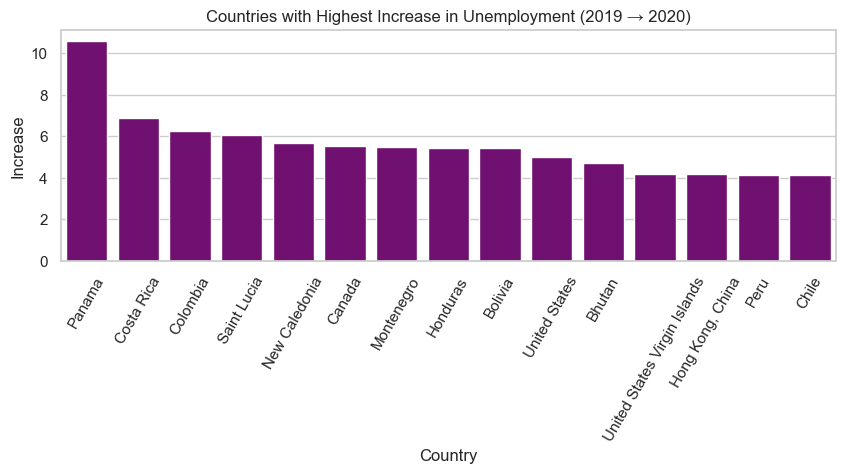

In [110]:
plt.figure(figsize=(10,3))
sns.barplot(
    x=increase_df.index,
    y=increase_df["increase"],
    color = 'purple'
)
plt.xticks(rotation=60)
plt.title("Countries with Highest Increase in Unemployment (2019 → 2020)")
plt.xlabel("Country")
plt.ylabel("Increase")
plt.show()

In [111]:
# recovery analysis of 2024 - 2020
recovery = (
    df_long[df_long["year"].isin([2020, 2024])]
    .pivot_table(
        index="country",
        columns="year",
        values="unemployment_rate",
        aggfunc="mean"
    )
)
recovery["recovery"] = recovery[2024] - recovery[2020]
recovery = recovery.sort_values("recovery")
recovery.head(15)

year,2020,2024,recovery
country,,,
Costa Rica,23.982000,12.794000,-11.188000
Panama,20.356833,10.890833,-9.466000
Brazil,18.505500,10.670167,-7.835333
Greece,21.928667,14.142000,-7.786667
Colombia,19.847667,12.517333,-7.330333
Guyana,19.769833,12.556500,-7.213333
Argentina,17.211833,10.282833,-6.929000
Saudi Arabia,18.553500,11.668833,-6.884667
South America,16.291833,9.763667,-6.528167


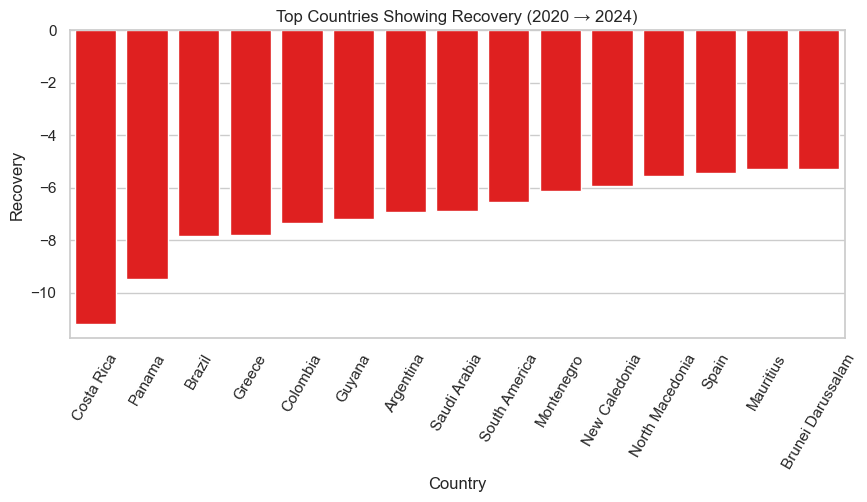

In [114]:
plt.figure(figsize=(10,4))
sns.barplot(
    x=recovery.head(15).index,
    y=recovery.head(15)["recovery"],
    color = 'red'
)
plt.xticks(rotation=60)
plt.title("Top Countries Showing Recovery (2020 → 2024)")
plt.xlabel("Country")
plt.ylabel("Recovery")
plt.show()

In [116]:
# nteractive country terend:
top10_country = (
    df_long
    .groupby("country")["unemployment_rate"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index
)
trend = df_long[
    df_long["country"].isin(top10_country)
]
fig = px.line(
    trend,
    x="year",
    y="unemployment_rate",
    color="country",
    title="Top 10 Countries Unemployment Trend",
    markers=True
)
fig.show()

# 📈 Trend Analysis & Statistical Insights

## Overview

This section focuses on identifying long-term unemployment trends, seasonal patterns, and statistical characteristics of the dataset. It also summarizes key findings and provides policy recommendations based on the analysis.

In [117]:
# Calculate 3-Year Moving Average
yearly_average["Moving_Average"] = (
    yearly_average["unemployment_rate"]
    .rolling(window=3)
    .mean()
)
yearly_average

,year,unemployment_rate,Moving_Average
0,2014,11.387800,NaN
1,2015,11.272444,NaN
2,2016,11.122963,11.261069
3,2017,10.863516,11.086308
4,2018,10.516499,10.834326
5,2019,10.311452,10.563822
6,2020,11.851285,10.893079
7,2021,11.422645,11.195127
8,2022,10.340361,11.204763
9,2023,9.985181,10.582729


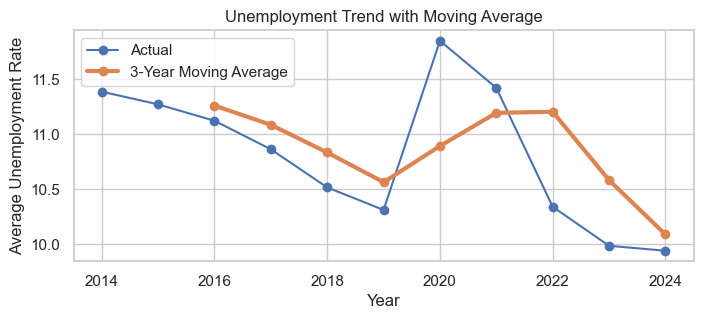

In [118]:
plt.figure(figsize=(8,3))
plt.plot(
    yearly_average["year"],
    yearly_average["unemployment_rate"],
    marker="o",
    label="Actual"
)
plt.plot(
    yearly_average["year"],
    yearly_average["Moving_Average"],
    marker="o",
    linewidth=3,
    label="3-Year Moving Average"
)
plt.title("Unemployment Trend with Moving Average")
plt.xlabel("Year")
plt.ylabel("Average Unemployment Rate")
plt.legend()
plt.grid(True)
plt.show()

In [119]:
# year to year change:
yearly_average["Yearly_Change"] = (
    yearly_average["unemployment_rate"]
    .diff()
)
yearly_average

,year,unemployment_rate,Moving_Average,Yearly_Change
0,2014,11.387800,NaN,NaN
1,2015,11.272444,NaN,-0.115355
2,2016,11.122963,11.261069,-0.149481
3,2017,10.863516,11.086308,-0.259447
4,2018,10.516499,10.834326,-0.347017
5,2019,10.311452,10.563822,-0.205047
6,2020,11.851285,10.893079,1.539832
7,2021,11.422645,11.195127,-0.428640
8,2022,10.340361,11.204763,-1.082284
9,2023,9.985181,10.582729,-0.355180


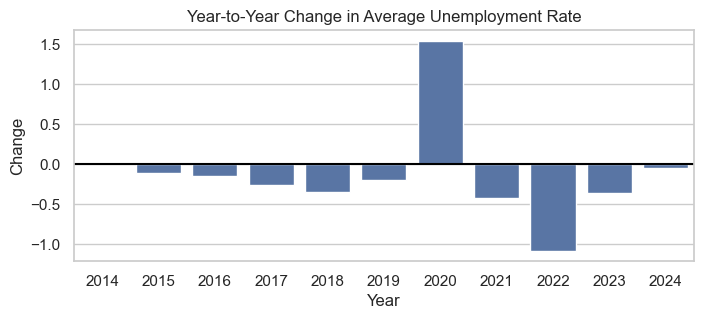

In [120]:
plt.figure(figsize=(8,3))
sns.barplot(
    data=yearly_average,
    x="year",
    y="Yearly_Change"
)
plt.axhline(0, color="black")
plt.title("Year-to-Year Change in Average Unemployment Rate")
plt.xlabel("Year")
plt.ylabel("Change")
plt.show()

In [121]:
# statistical measures:
print("Mean :", round(df_long["unemployment_rate"].mean(),2))
print("Median :", round(df_long["unemployment_rate"].median(),2))
print("Minimum :", round(df_long["unemployment_rate"].min(),2))
print("Maximum :", round(df_long["unemployment_rate"].max(),2))
print("Standard Deviation :", round(df_long["unemployment_rate"].std(),2))
print("Variance :", round(df_long["unemployment_rate"].var(),2))
print("Skewness :", round(df_long["unemployment_rate"].skew(),2))
print("Kurtosis :", round(df_long["unemployment_rate"].kurt(),2))

Mean : 10.82
Median : 7.09
Minimum : 0.03
Maximum : 83.99
Standard Deviation : 10.62
Variance : 112.8
Skewness : 2.13
Kurtosis : 5.93


## Seasonal Trend Analysis

The available dataset contains annual unemployment rates from 2014 to 2024.

Since no monthly or quarterly observations are available, seasonal trend analysis cannot be performed.

If monthly or quarterly unemployment data becomes available, seasonal decomposition techniques such as moving averages or seasonal indices can be applied.

In [122]:
# highest and lowest average year:
highest_year = yearly_average.loc[
    yearly_average["unemployment_rate"].idxmax()
]
lowest_year = yearly_average.loc[
    yearly_average["unemployment_rate"].idxmin()
]
print(highest_year)
print(lowest_year)

year                 2020.000000
unemployment_rate      11.851285
Moving_Average         10.893079
Yearly_Change           1.539832
Name: 6, dtype: float64
year                 2024.000000
unemployment_rate       9.940089
Moving_Average         10.088544
Yearly_Change          -0.045092
Name: 10, dtype: float64


In [123]:
# interacyive trend:
fig = px.area(
    yearly_average,
    x="year",
    y="unemployment_rate",
    title="Global Unemployment Trend"
)
fig.show()

In [124]:
df_long.to_csv(
    "Final_Unemployment_Analysis.csv",
    index=False
)
print("Final Dataset Exported Successfully!")

Final Dataset Exported Successfully!


# ✅ Conclusion

This project analyzed unemployment trends from 2014 to 2024 using Python for data cleaning, exploration, visualization, and statistical analysis.

The analysis highlighted significant changes in unemployment during the Covid-19 pandemic and demonstrated how unemployment varies across countries, genders, and age groups.

The findings can help researchers and policymakers better understand labor market conditions and support informed economic planning.